# Heart Disease Prediction with K-Nearest Neighbors (KNN)

Reproduction and extension of the article:

> **"Enhancing Prognosis Accuracy for Ischemic Cardiovascular Disease Using K Nearest Neighbor Algorithm: A Robust Approach"**

Dataset used: [Heart Disease Dataset (Kaggle)](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset).


## 1. Objectives

In this notebook we will:

1. Load and explore the **heart disease dataset**.
2. Perform **exploratory data analysis (EDA)**.
3. Apply **preprocessing** (encoding and scaling).
4. Train and evaluate a **K-Nearest Neighbors (KNN)** classifier.
5. Tune the hyperparameter **k** and compare performance.
6. Optionally compare KNN with other models (Logistic Regression, SVM, Random Forest).
7. Discuss results in light of the original article.


## 2. Imports


In [1]:
import kagglehub
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Loading the dataset


In [2]:
# Download dataset from KaggleHub (in Colab this will use a cache directory)
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
print("Dataset path:", path)

# List files to check what is available
files = os.listdir(path)
print("Available files:", files)

# We expect a file called 'heart.csv'
csv_file = os.path.join(path, "heart.csv")
diseases = pd.read_csv(csv_file)

diseases.head()

100%|██████████| 6.18k/6.18k [00:00<00:00, 2.65MB/s]

Extracting files...
Dataset path: /Users/brunoribeiro/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2
Available files: ['heart.csv']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 3.1. Basic information about the dataset


In [3]:
diseases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
diseases.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### 3.2. Feature description

Below is a short description of each column (you can adapt/translate from the dataset documentation or article):

- **age** – age in years
- **sex** – sex (1 = male, 0 = female)
- **cp** – chest pain type (4 values)
- **trestbps** – resting blood pressure (in mm Hg)
- **chol** – serum cholesterol in mg/dl
- **fbs** – fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- **restecg** – resting electrocardiographic results (values 0, 1, 2)
- **thalach** – maximum heart rate achieved
- **exang** – exercise induced angina (1 = yes, 0 = no)
- **oldpeak** – ST depression induced by exercise relative to rest
- **slope** – the slope of the peak exercise ST segment
- **ca** – number of major vessels (0–3) colored by fluoroscopy
- **thal** – thalassemia (0 = normal; 1 = fixed defect; 2 = reversible defect)
- **target** – 1 = presence of heart disease, 0 = absence


## 4. Checking missing values


In [5]:
diseases.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 5. Exploratory Data Analysis (EDA)


### 5.1. Numerical vs categorical features


In [6]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

summary_numeric = pd.DataFrame(
    {
        "mean": diseases[numeric_cols].mean(),
        "median": diseases[numeric_cols].median(),
        "std": diseases[numeric_cols].std(),
    }
)

print("Summary of numerical columns:")
display(summary_numeric)

print("\nValue counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(diseases[col].value_counts())

Summary of numerical columns:


,mean,median,std
age,54.434146,56.0,9.072290
trestbps,131.611707,130.0,17.516718
chol,246.000000,240.0,51.592510
thalach,149.114146,152.0,23.005724
oldpeak,1.071512,0.8,1.175053



Value counts for categorical columns:

Column: sex
sex
1    713
0    312
Name: count, dtype: int64

Column: cp
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

Column: fbs
fbs
0    872
1    153
Name: count, dtype: int64

Column: restecg
restecg
1    513
0    497
2     15
Name: count, dtype: int64

Column: exang
exang
0    680
1    345
Name: count, dtype: int64

Column: slope
slope
1    482
2    469
0     74
Name: count, dtype: int64

Column: ca
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

Column: thal
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64


### 5.2. Univariate distributions


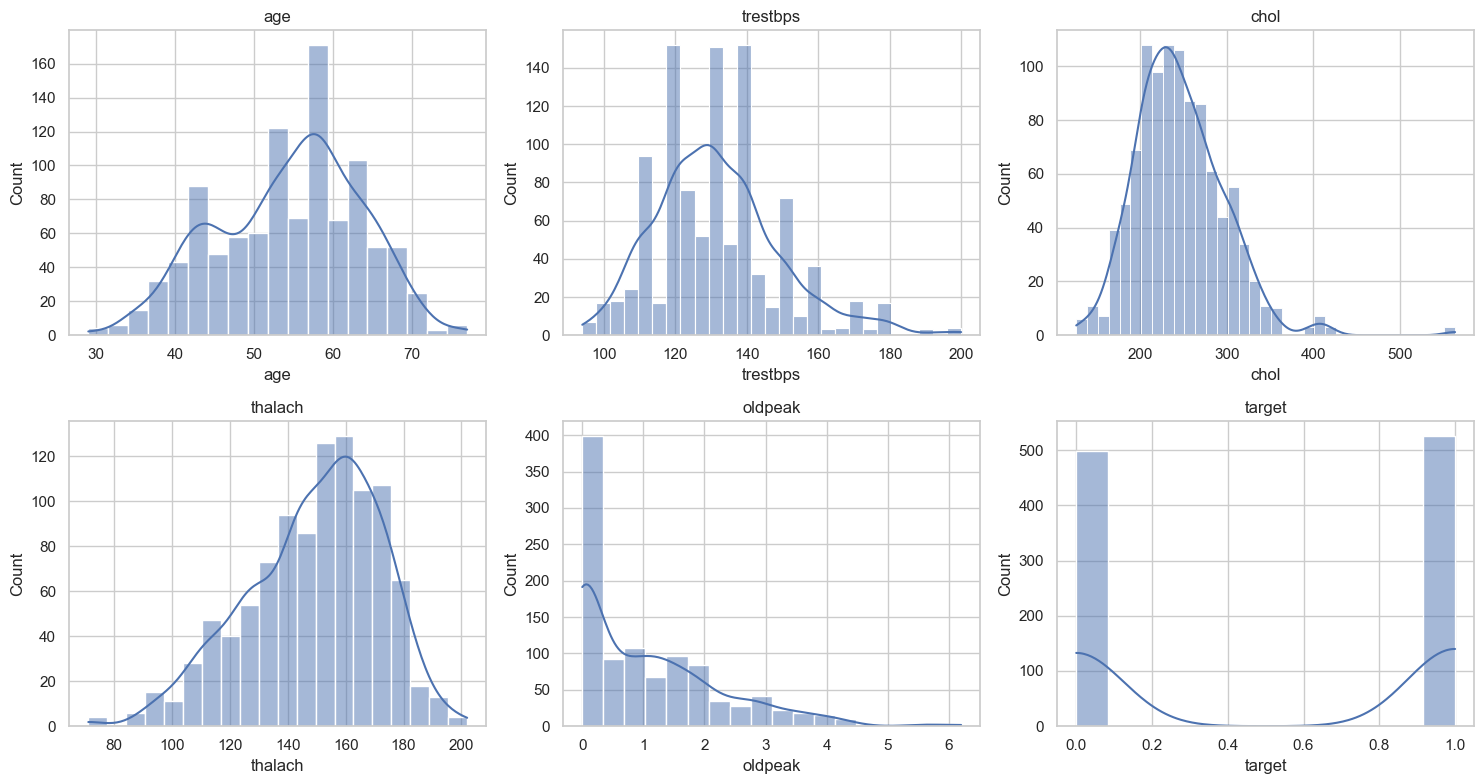

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

cols_to_plot = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]

for ax, col in zip(axes, cols_to_plot):
    sns.histplot(data=diseases, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 5.3. Relationship between features and target


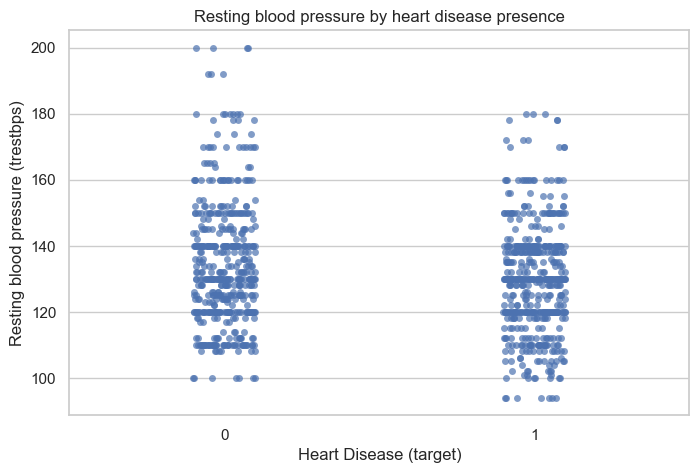

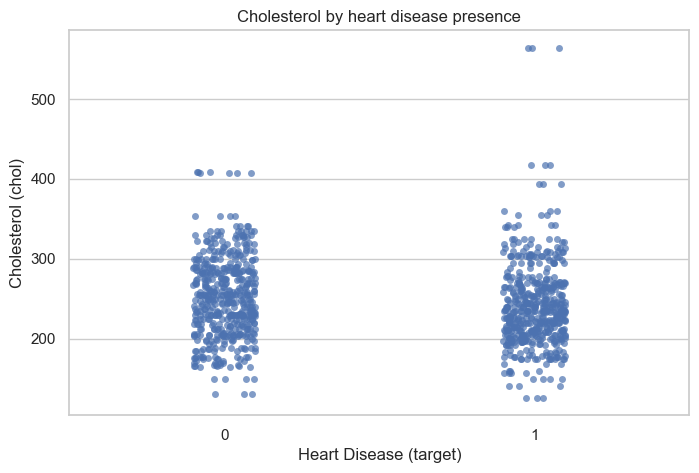

In [8]:
# Example: resting blood pressure vs target
sns.stripplot(data=diseases, x="target", y="trestbps", jitter=True, alpha=0.7)
plt.xlabel("Heart Disease (target)")
plt.ylabel("Resting blood pressure (trestbps)")
plt.title("Resting blood pressure by heart disease presence")
plt.show()

# Example: cholesterol vs target
sns.stripplot(data=diseases, x="target", y="chol", jitter=True, alpha=0.7)
plt.xlabel("Heart Disease (target)")
plt.ylabel("Cholesterol (chol)")
plt.title("Cholesterol by heart disease presence")
plt.show()

### 5.4. Correlation matrix


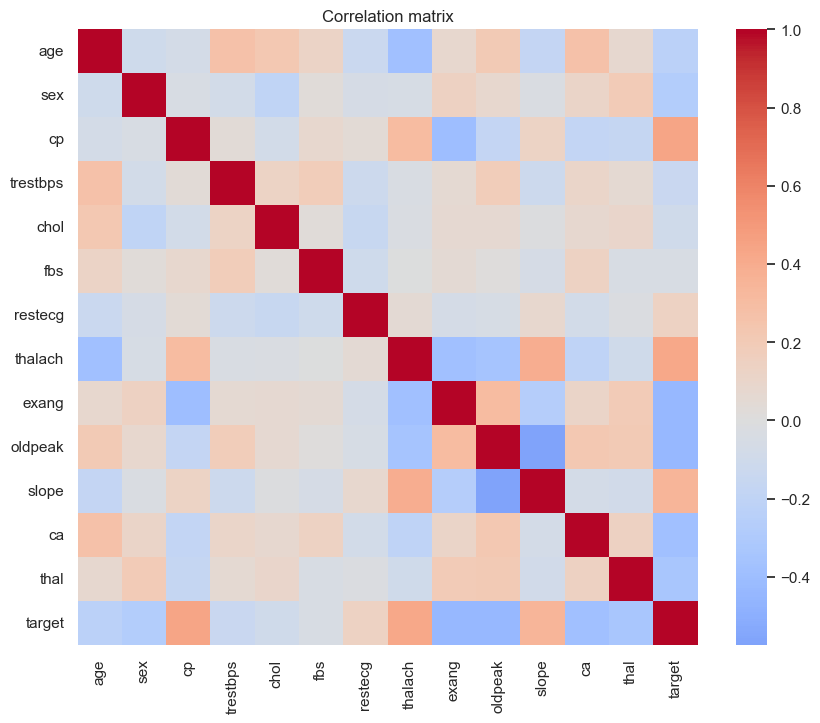

In [9]:
corr = diseases.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

## 6. Preprocessing


Steps:

1. Separate features (**X**) and target (**y**).
2. Apply **one-hot encoding** to categorical variables.
3. Split into **training and test** sets.
4. Apply **standardization** (StandardScaler) to numeric features.


In [10]:
# 6.1. Separate X and y
X = diseases.drop("target", axis=1)
y = diseases["target"]

# 6.2. One-hot encoding for categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,True,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,False,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False


In [11]:
# 6.3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (820, 22)
Test shape: (205, 22)


In [12]:
# 6.4. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Baseline KNN model


In the article, a specific value of **k** is chosen (e.g., k = 5 or another value).  
Here we start with a baseline value (k = 5). You should later adjust **k** to match the article or test several values.


In [13]:
k_baseline = 5  # adjust to match the article if needed

knn = KNeighborsClassifier(n_neighbors=k_baseline)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Baseline KNN (k={k_baseline})")
print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Baseline KNN (k=5)
Accuracy: 0.8292682926829268
ROC AUC: 0.9526190476190475

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.85      0.81      0.83       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



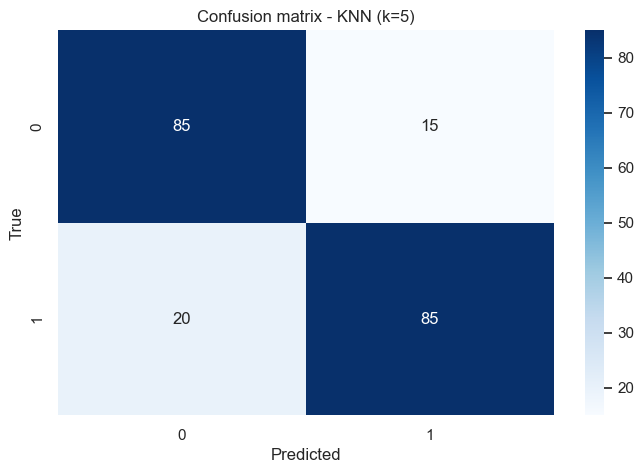

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix - KNN (k={k_baseline})")
plt.show()

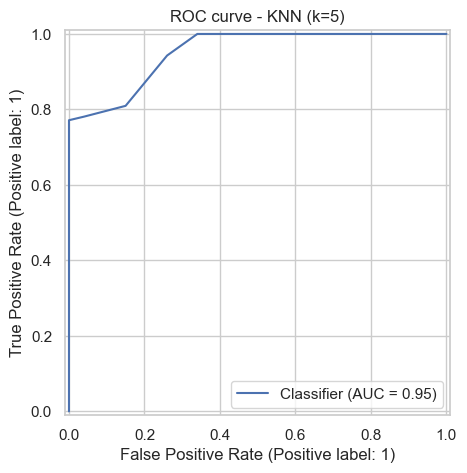

In [15]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC curve - KNN (k={k_baseline})")
plt.show()

## 8. Hyperparameter tuning: finding the best k


In [16]:
k_values = range(1, 31)
accuracies = []
roc_aucs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    y_prob_k = model.predict_proba(X_test_scaled)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred_k))
    roc_aucs.append(roc_auc_score(y_test, y_prob_k))

results_knn = pd.DataFrame(
    {"k": list(k_values), "accuracy": accuracies, "roc_auc": roc_aucs}
)

results_knn.head()

,k,accuracy,roc_auc
0,1,1.000000,1.000000
1,2,0.951220,0.995714
2,3,0.907317,0.982476
3,4,0.848780,0.964000
4,5,0.829268,0.952619


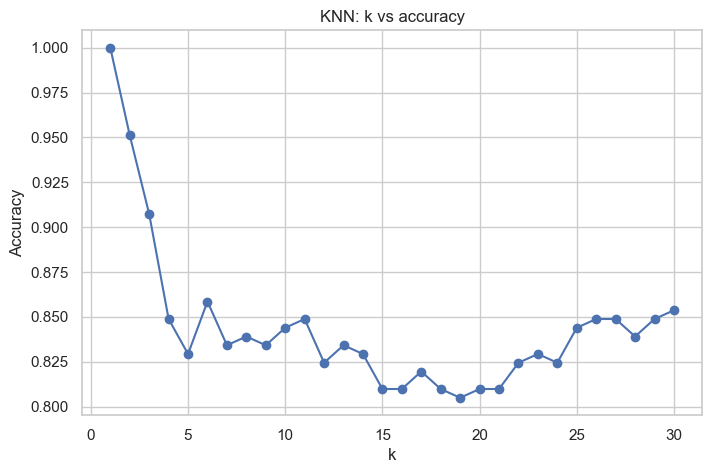

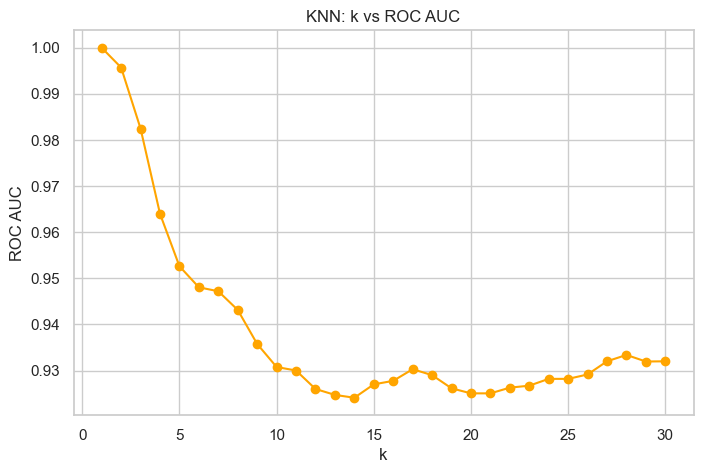

In [17]:
plt.plot(results_knn["k"], results_knn["accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN: k vs accuracy")
plt.grid(True)
plt.show()

plt.plot(results_knn["k"], results_knn["roc_auc"], marker="o", color="orange")
plt.xlabel("k")
plt.ylabel("ROC AUC")
plt.title("KNN: k vs ROC AUC")
plt.grid(True)
plt.show()

## 9. Comparing KNN with other models


In [18]:
models = {
    "KNN (best k)": KNeighborsClassifier(
        n_neighbors=results_knn.loc[results_knn["accuracy"].idxmax(), "k"]
    ),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
}

metrics = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_m = model.predict(X_test_scaled)
    y_prob_m = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_m)
    auc = roc_auc_score(y_test, y_prob_m)
    metrics.append({"model": name, "accuracy": acc, "roc_auc": auc})

metrics_df = pd.DataFrame(metrics)
metrics_df

,model,accuracy,roc_auc
0,KNN (best k),1.000000,1.000000
1,LogisticRegression,0.868293,0.944000
2,SVM (RBF),0.931707,0.977619
3,RandomForest,1.000000,1.000000


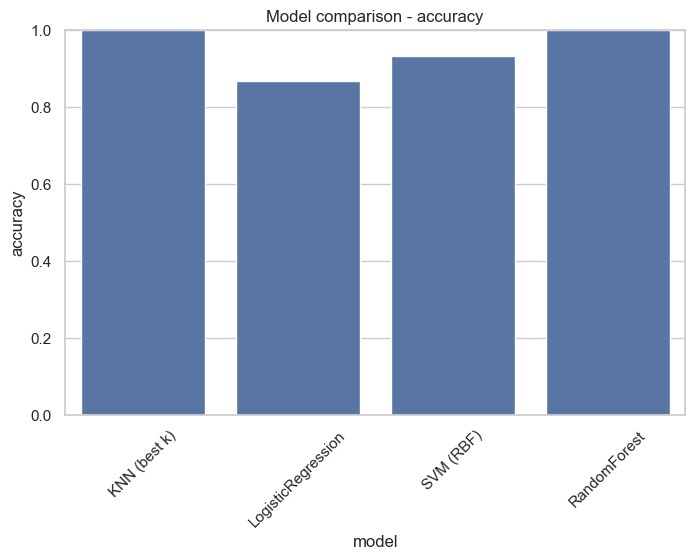

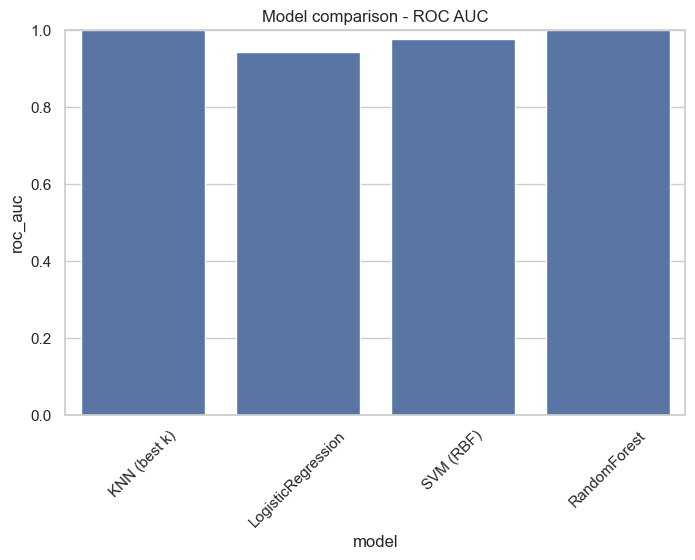

In [19]:
sns.barplot(data=metrics_df, x="model", y="accuracy")
plt.ylim(0, 1)
plt.title("Model comparison - accuracy")
plt.xticks(rotation=45)
plt.show()

sns.barplot(data=metrics_df, x="model", y="roc_auc")
plt.ylim(0, 1)
plt.title("Model comparison - ROC AUC")
plt.xticks(rotation=45)
plt.show()

## 10. Discussion and conclusions

Here you should:

- Compare the obtained results (accuracy, ROC AUC, confusion matrix) with those reported in the article.
- Discuss how the choice of **k** affects performance.
- Explain which model performed best in your experiments and why.
- Comment on possible limitations: dataset size, feature selection, class imbalance, etc.
- Suggest future improvements (feature engineering, cross-validation, other algorithms, etc.).
